# I. Package for the heat equation in dimensions 1+3

In [ ]:
# Allows to automatically switch from CPU to GPU
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

torch.set_default_dtype(torch.float64)

def is_running_on_gpu():
  if torch.cuda.is_available():
    print("The algorithm is running on GPU.")
  else:
    print("The algorithm is not running on GPU.")

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
def Sob_formula(k1, k2, k3, k4, j1, j2, j3, j4, s, L):
    diagonal = torch.logical_and(
        torch.logical_and(k1 == j1, k2 == j2),
        torch.logical_and(k3 == j3, k4 == j4)
    )
    return torch.where(diagonal, 1+ (k1**2 + k2**2+k3**2+k4**2)**s/(2*L)**(2*s), 0.)


def Sob_matrix(m, s, L, device):
  fourier_range = torch.arange(-m, m+1, device=device)
  k1, k2, k3, k4, j1, j2, j3, j4 = torch.meshgrid(*[fourier_range]*8, indexing='ij')
  k1 = k1.flatten()
  k2 = k2.flatten()
  k3 = k3.flatten()
  k4 = k4.flatten()
  j1 = j1.flatten()
  j2 = j2.flatten()
  j3 = j3.flatten()
  j4 = j4.flatten()

  sob_values = Sob_formula(k1, k2, k3, k4, j1, j2, j3, j4, s, L)

  return sob_values.view((2*m+1)**4, (2*m+1)**4)

In [ ]:
def Fourier_PDE(k1, k2, k3, k4, j1, j2, j3, j4,  L):
  diagonal = torch.logical_and(
        torch.logical_and(k1 == j1, k2 == j2),
        torch.logical_and(k3 == j3, k4 == j4)
    )

  return torch.where(diagonal, 1j*k1*torch.pi/2-torch.pi**2/4*(k2**2+k3**2+k4**2), 0.)

def PDE_matrix(m, L, device):
  fourier_range = torch.arange(-m, m+1, device=device)
  k1, k2, k3, k4, j1, j2, j3, j4 = torch.meshgrid(*[fourier_range]*8, indexing='ij')
  k1 = k1.flatten()
  k2 = k2.flatten()
  k3 = k3.flatten()
  k4 = k4.flatten()
  j1 = j1.flatten()
  j2 = j2.flatten()
  j3 = j3.flatten()
  j4 = j4.flatten()

  PDE_values = Fourier_PDE(k1, k2, k3, k4, j1, j2, j3, j4,  L)

  return PDE_values.view((2*m+1)**4, (2*m+1)**4)

In [ ]:
def Omega_matrix(m, device):
    fourier_range = torch.arange(-m, m+1, device=device)
    k1, k2, k3, k4, j1, j2, j3, j4 = torch.meshgrid(*[fourier_range]*8, indexing='ij')
    k1 = (k1-j1).flatten()
    k2 = (k2-j2).flatten()
    k3 = (k3-j3).flatten()
    k4 = (k4-j4).flatten()
    j1, j2, j3, j4 = None, None, None, None

    T_values =  torch.sinc(k1/2)*torch.sinc(k2/2)*torch.sinc(k3/2)*torch.sinc(k4/2)/16

    return T_values.view((2*m+1)**4, (2*m+1)**4)

In [ ]:
def phi_matrix(mat_xs, js, L):
  mat_x1, mat_x2, mat_x3, mat_x4 = mat_xs
  j1, j2, j3, j4 = js
  return torch.exp(torch.pi/L*(torch.mul(mat_x1, j1)+
                               torch.mul(mat_x2, j2)+
                               torch.mul(mat_x3, j3)+
                               torch.mul(mat_x4, j4))*1j/2)

def M_mat(s, m, lambda_n, mu_n, L, device):
  S = Sob_matrix(m, s, L, device)*(1.0+0*1j)
  P = PDE_matrix(m, L, device)*(1.0+0*1j)
  T = Omega_matrix(m, device)*(1.0+0*1j)
  M = lambda_n * S + mu_n * torch.transpose(torch.conj_physical(P), 0, 1)@T@P
  return M

def RFF_fit(data_x, data_y, s, m, lambda_n, mu_n, L, device):
  data_x1= data_x[:, 0]
  data_x2= data_x[:, 1]
  data_x3= data_x[:, 2]
  data_x4= data_x[:, 3]

  M = M_mat(s, m, lambda_n, mu_n, L, device)
  return RFF(m, data_x1, data_x2, data_x3, data_x4, data_y,  L, M, device)

def RFF(m, data_x1, data_x2, data_x3, data_x4, data_y,  L, M, device):
  l = len(data_x1)

  mat_x1 = torch.tile(data_x1, ((2*m+1)**4,1))
  mat_x2 = torch.tile(data_x2, ((2*m+1)**4,1))
  mat_x3 = torch.tile(data_x3, ((2*m+1)**4,1))
  mat_x4 = torch.tile(data_x4, ((2*m+1)**4,1))
  mat_xs = [mat_x1, mat_x2, mat_x3, mat_x4]

  fourier_range = torch.arange(-m, m+1, device=device)
  fourier_rangex = torch.arange(l, device=device)

  j1, j2, j3, j4,  k1 = torch.meshgrid( fourier_range, fourier_range, fourier_range, fourier_range, fourier_rangex, indexing='ij')
  j1 = j1.flatten().view((2*m+1)**4, l)
  j2 = j2.flatten().view((2*m+1)**4, l)
  j3 = j3.flatten().view((2*m+1)**4, l)
  j4 = j4.flatten().view((2*m+1)**4, l)
  js = [j1, j2, j3, j4]

  phi_mat = phi_matrix(mat_xs, js, L)

  RFF_mat = phi_mat@torch.conj_physical(torch.transpose(phi_mat, 0, 1))
  data_y = data_y*(1.+0*1j)
  return torch.linalg.solve(RFF_mat+l*M, phi_mat@data_y)

In [ ]:
def phi_z_mat(m, data_z1, data_z2, data_z3, data_z4, L, device):
  l2 = len(data_z1)

  mat_z1 = torch.tile(data_z1, ((2*m+1)**4,1))
  mat_z2 = torch.tile(data_z2, ((2*m+1)**4,1))
  mat_z3 = torch.tile(data_z3, ((2*m+1)**4,1))
  mat_z4 = torch.tile(data_z4, ((2*m+1)**4,1))
  mat_zs = [mat_z1, mat_z2, mat_z3, mat_z4]

  fourier_range = torch.arange(-m, m+1, device=device)
  fourier_rangez = torch.arange(l2, device=device)
  jz1, jz2, jz3, jz4, k1 = torch.meshgrid(fourier_range, fourier_range, fourier_range, fourier_range, fourier_rangez,  indexing='ij')
  jz1 = jz1.flatten().view((2*m+1)**4, l2)
  jz2 = jz2.flatten().view((2*m+1)**4, l2)
  jz3 = jz3.flatten().view((2*m+1)**4, l2)
  jz4 = jz4.flatten().view((2*m+1)**4, l2)
  js = [jz1, jz2, jz3, jz4]


  phi_z = phi_matrix(mat_zs, js, L)
  return phi_z


def RFF_estimate(regression_vect, data_z, s, m, lambda_n, mu_n, L, device):
  data_z1= data_z[:, 0]
  data_z2= data_z[:, 1]
  data_z3= data_z[:, 2]
  data_z4= data_z[:, 3]

  phi_z = phi_z_mat(m, data_z1, data_z2, data_z3, data_z4, L, device)
  estimator = torch.transpose(torch.conj_physical(phi_z), 0,1)@regression_vect
  return estimator

# II. PIKL regression

In [ ]:
torch.manual_seed(746)

s = 3
L = 1
m = 3

std = 0.01 #Standard deviation of the Gaussian noise

mu_n =  1

In [ ]:
def ground_truth(x1, x2, x3, x4):
  return torch.exp(-3*x1/torch.pi**2)*torch.cos(x2/torch.pi)*torch.cos(x3/torch.pi)*torch.cos(x4/torch.pi)

In [ ]:
n_test = 10**2

n_train_list = [int(10**(i/2)) for i in range(2, 11)]
err_list = []
std_list = []

for n_train in n_train_list:
  print("N_train = ", n_train)
  lambda_n = 10**-5*n_train**(-1)

  err = []
  for i in range(5):
    ### Data generation
    n_BC = (3*n_train)//4
    data_x = torch.rand((n_BC, 4), device=device)-0.5

    row_indices = torch.arange(n_BC, device=device).view(-1, 1)
    col_indices = torch.randint(1, 4, (n_BC, 1), device=device)
    face = torch.randint(2, (n_BC,1), device=device)-0.5
    data_x[row_indices, col_indices] = face # Projecting on random faces

    initial_conditions = torch.rand((n_train-n_BC, 4), device=device)-0.5
    initial_conditions[:, 0] = -0.5
    data_x = torch.cat((data_x, initial_conditions), dim=0)

    data_y = ground_truth(data_x[:,0], data_x[:,1], data_x[:,2], data_x[:,3]) + torch.normal(0, std, (n_train,), device=device)

    ### Testing data
    data_x_test = torch.rand((n_train, 4), device=device)-0.5
    data_y_test = ground_truth(data_x_test[:,0], data_x_test[:,1], data_x_test[:,2], data_x_test[:,3])

    ### Regression
    regression_vect = RFF_fit(data_x, data_y, s, m, lambda_n, mu_n, L, device)

    estimator = torch.real(RFF_estimate(regression_vect, data_x_test, s, m, lambda_n, mu_n, L, device))

    error_u = np.sqrt(torch.mean(torch.square(torch.abs(estimator - data_y_test))).item())/np.sqrt(torch.mean(torch.square(data_y_test)).item())
    err.append(error_u)


  err_list.append(np.mean(err)) #Relative L2 error_u
  std_list.append(np.std(err))


N_train =  10
N_train =  31
N_train =  100
N_train =  316
N_train =  1000
N_train =  3162
N_train =  10000
N_train =  31622
N_train =  100000


<ipython-input-35-a0ff9729f3d5>:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20c')


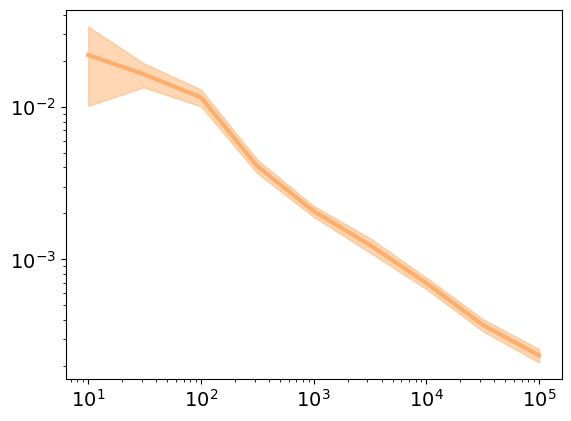

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors

plt.rcParams.update({'font.size': 14})

cmap = cm.get_cmap('tab20c')


y1_color = cmap(1/20) #bleu
y2_color = cmap(6/20) #orange
y3_color = cmap(9/20) #vert
y4_color = cmap(14/20) #violet

err_list = np.array(err_list)
std_list = np.array(std_list)

plt.plot(n_train_list, err_list, linestyle='-',linewidth=3, color=y2_color)
plt.fill_between(n_train_list, err_list-std_list, err_list+std_list, alpha=0.5,color=y2_color)


plt.xscale('log')
plt.yscale('log')

In [ ]:
err_list

array([0.04586587, 0.0141702 , 0.00615924, 0.00306703, 0.00178805,
       0.00094535, 0.00060996, 0.00035168, 0.00020142])

In [ ]:
n_train_list

[10, 31, 100, 316, 1000, 3162, 10000, 31622, 100000]

In [ ]:
m, b = np.polyfit(np.log(n_train_list), np.log(err_list), 1)
print("The convergence rate in the L2 relative norm is ", m, ".")
print("As a comparison, the Sobolev minimax rate with s=3 is -0.3 and the parametric rate is -0.5.")

The convergence rate in the L2 relative norm is  -0.5252231484026341 .
As a comparison, the Sobolev minimax rate with s=3 is -0.3 and the parametric rate is -0.5.


# III. PINNs

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the neural network
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.activation = nn.Tanh()
        self.layers = nn.ModuleList()

        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
            nn.init.xavier_normal_(self.layers[-1].weight)
            nn.init.zeros_(self.layers[-1].bias)

    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = self.activation(layer(x))
        x = self.layers[-1](x)
        return x

# Define the physics loss
class HeatEquationPINN:
    def __init__(self, model, boundary_conditions):
        self.model = model.to(device)
        self.boundary_conditions = boundary_conditions

    def residual_loss(self, x, y, z, t):
        """ Compute the PDE residual loss """

        inputs = torch.cat([x, y, z, t], dim=1)
        u = self.model(inputs)

        grads = torch.autograd.grad(u, inputs, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_t = grads[:, 3:4]
        u_xx = torch.autograd.grad(grads[:, 0:1], x, grad_outputs=torch.ones_like(x), create_graph=True)[0]
        u_yy = torch.autograd.grad(grads[:, 1:2], y, grad_outputs=torch.ones_like(y), create_graph=True)[0]
        u_zz = torch.autograd.grad(grads[:, 2:3], z, grad_outputs=torch.ones_like(z), create_graph=True)[0]

        return ((u_t - (u_xx + u_yy + u_zz)) ** 2).mean()

    def boundary_loss(self):
        """ Compute loss for boundary/initial conditions """
        x_b, y_b, z_b, t_b, u_b = self.boundary_conditions
        u_pred = self.model(torch.cat([x_b, y_b, z_b, t_b], dim=1))
        return ((u_pred - u_b) ** 2).mean()

    def total_loss(self, x, y, z, t):
        return self.residual_loss(x, y, z, t) + self.boundary_loss()


In [ ]:
def evaluate_pinn(model, test_points):
    model.eval()
    test_points = test_points.to(device)
    with torch.no_grad():
        u_pred = model(test_points)
    return u_pred.cpu().numpy()


In [ ]:
layers = [4, 10, 10, 10, 1]

n_test = 10**2

n_train_list = [int(10**(i/2)) for i in range(2, 11)]
err_list_PINNs = []
std_list_PINNs = []

for n_train in n_train_list:
  print("N_train = ", n_train)


  err = []

  for i in range(5):
    # Boundary conditions
    model = PINN(layers)

    n_BC = (3*n_train)//4
    data_x = torch.rand((n_BC, 4), device=device)-0.5

    row_indices = torch.arange(n_BC, device=device).view(-1, 1)
    col_indices = torch.randint(1, 4, (n_BC, 1), device=device)
    face = torch.randint(2, (n_BC,1), device=device)-0.5
    data_x[row_indices, col_indices] = face # Projecting on random faces

    initial_conditions = torch.rand((n_train-n_BC, 4), device=device)-0.5
    initial_conditions[:, 0] = -0.5
    data_x = torch.cat((data_x, initial_conditions), dim=0)

    data_y = ground_truth(data_x[:,0], data_x[:,1], data_x[:,2], data_x[:,3]) + torch.normal(0, std, (n_train,), device=device)
    boundary_conditions = (data_x[:,0].unsqueeze(1), data_x[:,1].unsqueeze(1), data_x[:,2].unsqueeze(1), data_x[:,3].unsqueeze(1), data_y.unsqueeze(1))


    # Training loop
    pinn = HeatEquationPINN(model, boundary_conditions)

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(2*10**3+1):
        x_colloc = torch.rand(100, 1, requires_grad=True, device=device)
        y_colloc = torch.rand(100, 1, requires_grad=True, device=device)
        z_colloc = torch.rand(100, 1, requires_grad=True, device=device)
        t_colloc = torch.rand(100, 1, requires_grad=True, device=device)

        optimizer.zero_grad()
        loss = pinn.total_loss(x_colloc, y_colloc, z_colloc, t_colloc)
        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item()}')

    # Generate test points

    data_x_test = torch.rand((n_train, 4), device=device)-0.5
    data_y_test = ground_truth(data_x_test[:,0], data_x_test[:,1], data_x_test[:,2], data_x_test[:,3])

    # Evaluate model on test points
    predicted_u = evaluate_pinn(model, data_x_test).flatten()
    errors = np.sqrt(np.mean(np.square(np.abs(predicted_u - data_y_test.cpu().numpy()))))/np.sqrt(np.mean(np.square(data_y_test.cpu().numpy())))

    err.append(errors)
  err_list_PINNs.append(np.mean(err)) #Relative L2 error_u
  std_list_PINNs.append(np.std(err))

N_train =  10
Epoch 0, Loss: 1.855410895230901
Epoch 500, Loss: 0.004258209016534578
Epoch 1000, Loss: 0.0007075062460874898
Epoch 1500, Loss: 0.00042734630452494947
Epoch 2000, Loss: 0.00031870937563900496
Epoch 0, Loss: 1.3839001403576128
Epoch 500, Loss: 0.002105119520984107
Epoch 1000, Loss: 0.0007134413766366672
Epoch 1500, Loss: 0.00037994190727484636
Epoch 2000, Loss: 0.0002025295958999391
Epoch 0, Loss: 2.0371523712913895
Epoch 500, Loss: 0.002182750376861478
Epoch 1000, Loss: 0.0006322774682394661
Epoch 1500, Loss: 0.0004473101009796571
Epoch 2000, Loss: 0.000147780686969145
Epoch 0, Loss: 1.7486468427228286
Epoch 500, Loss: 0.0006372978556488567
Epoch 1000, Loss: 0.0002756096590546445
Epoch 1500, Loss: 0.00023156157688202956
Epoch 2000, Loss: 0.00015714484978405173
Epoch 0, Loss: 2.5749112879165788
Epoch 500, Loss: 0.004775503970136431
Epoch 1000, Loss: 0.0023891484856533056
Epoch 1500, Loss: 0.0008014924759338406
Epoch 2000, Loss: 0.0005740246416304503
N_train =  31
Epoch 0,

<ipython-input-37-6ce3d0256438>:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20c')


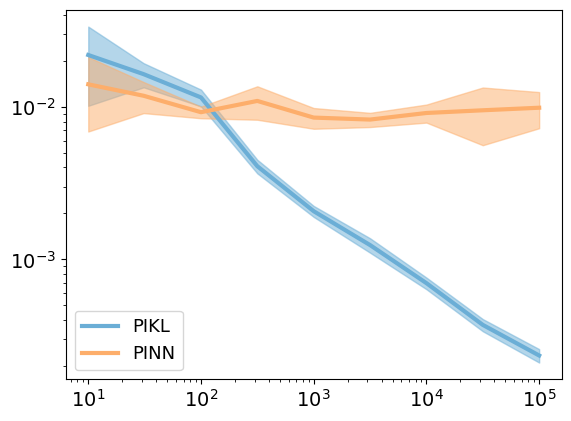

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors

plt.rcParams.update({'font.size': 14})

cmap = cm.get_cmap('tab20c')


y1_color = cmap(1/20) #bleu
y2_color = cmap(6/20) #orange
y3_color = cmap(9/20) #vert
y4_color = cmap(14/20) #violet

err_list = np.array(err_list)
std_list = np.array(std_list)
err_list_PINNs = np.array(err_list_PINNs)
std_list_PINNs = np.array(std_list_PINNs)

plt.plot(n_train_list, err_list, linestyle='-',linewidth=3, color=y1_color, label="PIKL")
plt.fill_between(n_train_list, err_list-std_list, err_list+std_list, alpha=0.5,color=y1_color)

plt.plot(n_train_list, err_list_PINNs, linestyle='-',linewidth=3, color=y2_color, label="PINN")
plt.fill_between(n_train_list, err_list_PINNs-std_list_PINNs, err_list_PINNs+std_list_PINNs, alpha=0.5,color=y2_color)


plt.xscale('log')
plt.yscale('log')

plt.legend(loc='lower left', fontsize=13)

# IV. Comparison to the constant model

The function $(x_1, x_2, x_3, x_4) \mapsto exp^{-3 x_1 / \pi^2} \cos( x_2 / \pi) \cos( x_3 / \pi) \cos( x_4 / \pi) $ is very flat and close to one. Thus, we compare the performance of our models to the constant function $(x_1, x_2, x_3, x_4) \mapsto \int\int\int\int exp^{-3 x_1 / \pi^2} \cos( x_2 / \pi) \cos( x_3 / \pi) \cos( x_4 / \pi) dx_1 dx_2 dx_3 dx_4$.

In [ ]:
from logging import error
import numpy as np
from scipy.integrate import nquad

def integrand(x1, x2, x3, x4):
    term = np.exp(-3 * x1 / np.pi**2) * np.cos(x2 / np.pi) * np.cos(x3 / np.pi) * np.cos(x4 / np.pi)
    return term

integral_f_star, error_f_star = nquad(integrand, [[-0.5, 0.5]] * 4)

print("Integral result:", integral_f_star)

def integrand_error(x1, x2, x3, x4):
    term = np.exp(-3 * x1 / np.pi**2) * np.cos(x2 / np.pi) * np.cos(x3 / np.pi) * np.cos(x4 / np.pi) - integral_f_star
    return term**2

def integrand(x1, x2, x3, x4):
    term = np.exp(-3 * x1 / np.pi**2) * np.cos(x2 / np.pi) * np.cos(x3 / np.pi) * np.cos(x4 / np.pi)
    return term**2

# Define integration limits
limits = [[-0.5, 0.5]] * 4

# Compute the integral
MSE, error_RMSE = nquad(integrand_error, limits)
scaling, error_scaling = nquad(integrand, limits)

# Compute the square root
L2_relative_error = np.sqrt(MSE/scaling)

print("Integral result:", L2_relative_error)

Integral result: 0.9912097864925209
Integral result: 0.0875880132833896


<ipython-input-39-bf8d54c38104>:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20c')


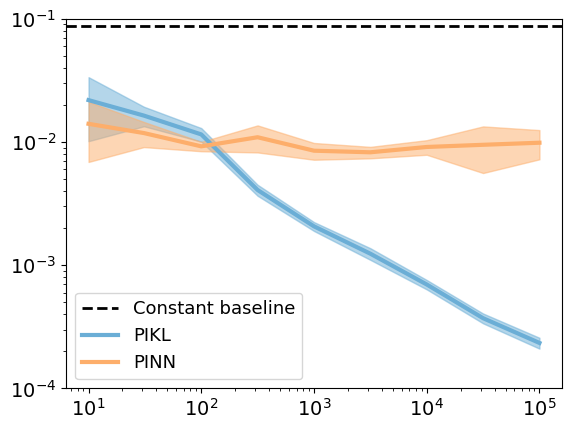

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors

plt.rcParams.update({'font.size': 14})

cmap = cm.get_cmap('tab20c')


y1_color = cmap(1/20) #bleu
y2_color = cmap(6/20) #orange
y3_color = cmap(9/20) #vert
y4_color = cmap(14/20) #violet

err_list = np.array(err_list)
std_list = np.array(std_list)
err_list_PINNs = np.array(err_list_PINNs)
std_list_PINNs = np.array(std_list_PINNs)

plt.axhline(y=L2_relative_error, color='k', linestyle='--', label="Constant baseline", linewidth=2)

plt.plot(n_train_list, err_list, linestyle='-',linewidth=3, color=y1_color, label="PIKL")
plt.fill_between(n_train_list, err_list-std_list, err_list+std_list, alpha=0.5,color=y1_color)

plt.plot(n_train_list, err_list_PINNs, linestyle='-',linewidth=3, color=y2_color, label="PINN")
plt.fill_between(n_train_list, err_list_PINNs-std_list_PINNs, err_list_PINNs+std_list_PINNs, alpha=0.5,color=y2_color)

plt.ylim((10**-4, 10**-1))
plt.xscale('log')
plt.yscale('log')

plt.legend(loc='lower left', fontsize=13)


plt.savefig('4D-heat.pdf', bbox_inches='tight')